In [16]:
import numpy as np # arithmetric math
import pandas as pd # data processing, CSV file
import matplotlib.pyplot as plt # graph 
import seaborn as sns # graph
from datetime import datetime 
import warnings
warnings.filterwarnings('ignore')

In [17]:
sns.set_style('whitegrid') # set style of chart
plt.rcParams['figure.figsize'] = (12,6)  # set size


In [ ]:
df = pd.read_csv("/kaggle/input/datasets/umuttuygurr/customer-behavior-and-sales-analysis-tr/customer_behavior_dataset.csv"
        )
df['Date'] = pd.to_datetime(df['Date']) # alter date from string to practically date format

In [19]:
df

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ORD_001048,CUST_01048,2024-03-26,18,Female,Izmir,Beauty,130.35,1,27.30,103.05,Bank Transfer,Mobile,17,10,False,9,1
4996,ORD_001051,CUST_01051,2024-03-26,27,Male,Adana,Beauty,71.55,1,0.00,71.55,Debit Card,Mobile,13,9,True,6,4
4997,ORD_003543,CUST_03543,2024-03-26,45,Female,Antalya,Food,39.38,1,5.27,34.11,Digital Wallet,Mobile,38,10,True,5,4
4998,ORD_004443,CUST_04443,2024-03-26,41,Female,Istanbul,Fashion,171.19,1,0.00,171.19,Credit Card,Mobile,20,12,True,5,4


In [20]:
print(df.shape)

(5000, 18)


In [21]:
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  5000 non-null   object        
 1   Customer_ID               5000 non-null   object        
 2   Date                      5000 non-null   datetime64[ns]
 3   Age                       5000 non-null   int64         
 4   Gender                    5000 non-null   object        
 5   City                      5000 non-null   object        
 6   Product_Category          5000 non-null   object        
 7   Unit_Price                5000 non-null   float64       
 8   Quantity                  5000 non-null   int64         
 9   Discount_Amount           5000 non-null   float64       
 10  Total_Amount              5000 non-null   float64       
 11  Payment_Method            5000 non-null   object        
 12  Device_Type         

In [23]:
df.isnull().sum()

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

In [24]:
df.describe()

,Date,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000
mean,2023-08-16 09:16:24.959999744,35.032600,455.834120,2.220000,24.852804,983.108914,14.57340,8.98420,6.497000,3.902800
min,2023-01-01 00:00:00,18.000000,5.180000,1.000000,0.000000,7.870000,1.00000,1.00000,1.000000,1.000000
25%,2023-04-30 00:00:00,27.000000,76.587500,1.000000,0.000000,122.517500,8.00000,7.00000,4.000000,3.000000
50%,2023-08-17 00:00:00,35.000000,182.950000,2.000000,0.000000,337.910000,13.00000,9.00000,6.000000,4.000000
75%,2023-12-06 00:00:00,42.000000,513.930000,3.000000,8.760000,979.695000,19.00000,11.00000,8.000000,5.000000
max,2024-03-26 00:00:00,75.000000,7159.450000,5.000000,1525.550000,22023.900000,73.00000,24.00000,25.000000,5.000000
std,NaN,11.080546,712.477209,1.398711,88.385124,1898.978528,8.66575,2.80434,3.464966,1.128542


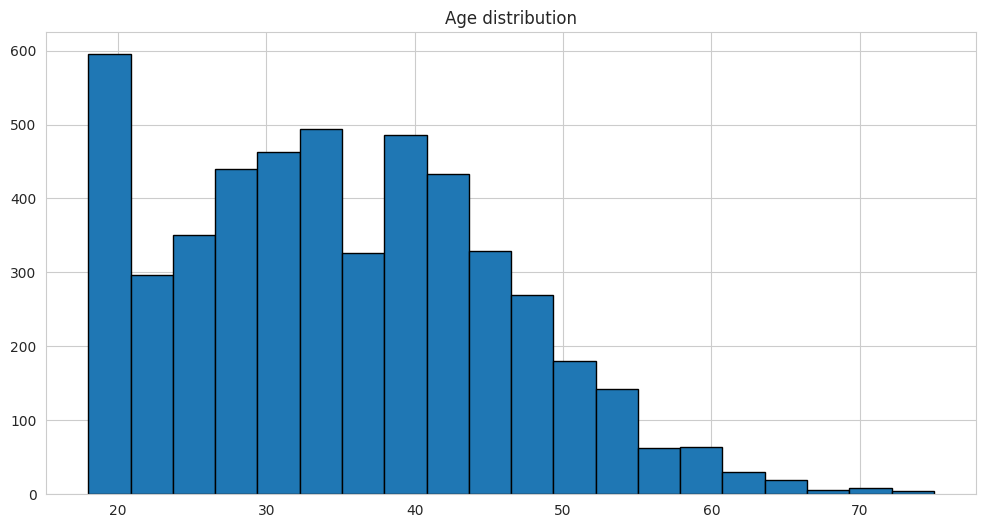

In [25]:
plt.hist(df['Age'], bins = 20, edgecolor = 'black')
plt.title("Age distribution")
plt.show()

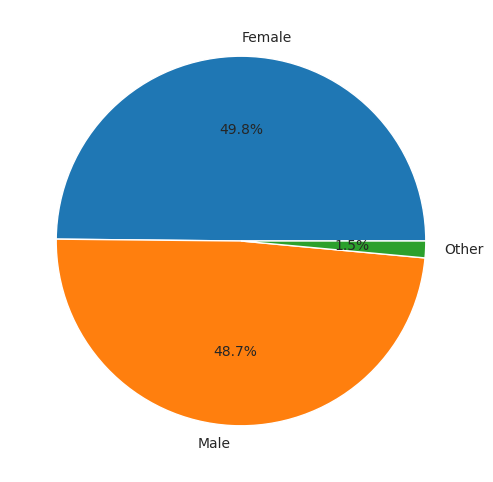

In [26]:
df['Gender'].value_counts().plot(kind = 'pie', autopct= '%1.1f%%')
plt.ylabel('')
plt.show()

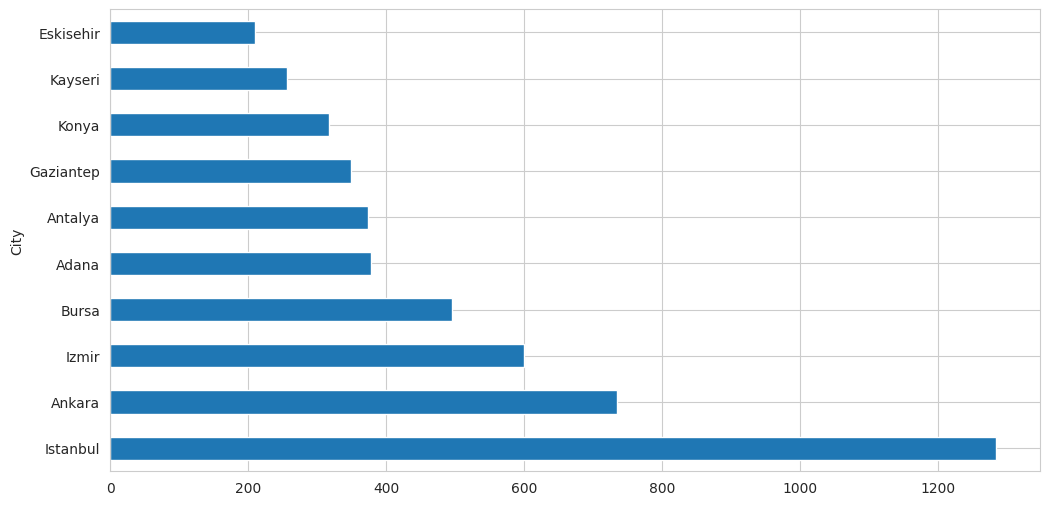

In [27]:
df['City'].value_counts().head(10).plot(kind = 'barh')
plt.show()

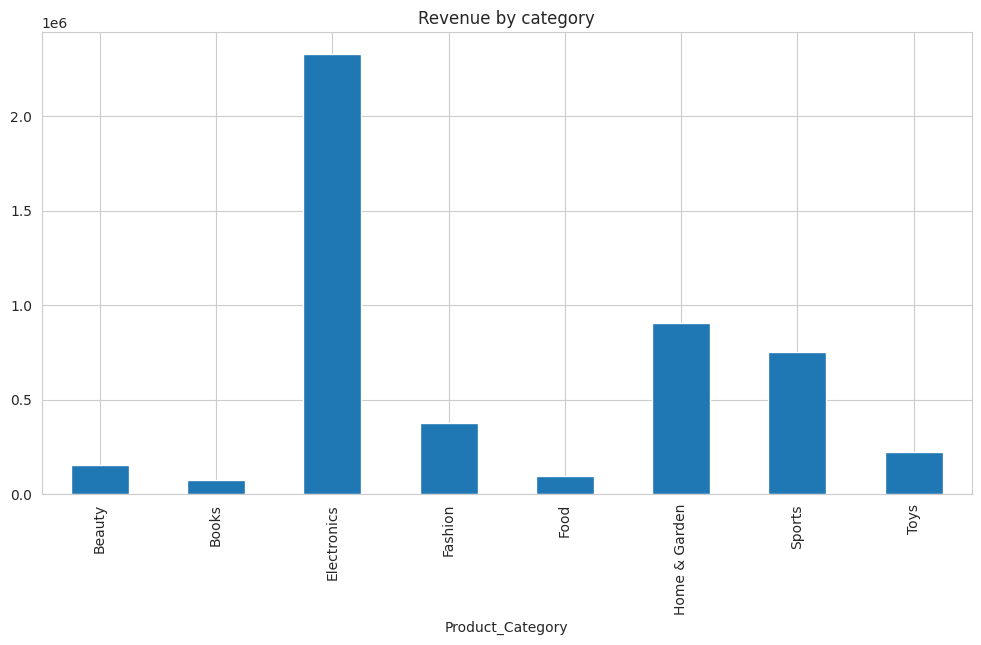

In [28]:
category_revenue = df.groupby("Product_Category")['Total_Amount'].sum()
category_revenue.plot(kind = 'bar')
plt.title('Revenue by category')
plt.show()
# Which category brings in the most money overall?”

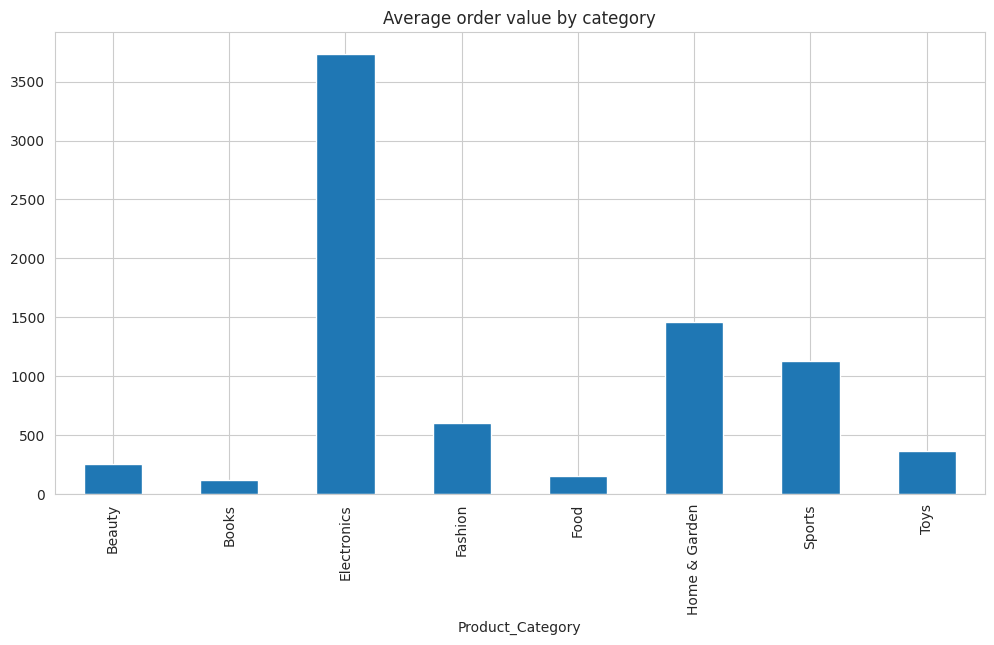

In [29]:
category_revenue = df.groupby("Product_Category")['Total_Amount'].mean().plot(kind = 'bar')
plt.title('Average order value by category') 
plt.show() 
# When someone buys from this category, how much do they usually spend?”
# It ignores volume and focuses on per-transaction value.

In [30]:
category_stats = df.groupby("Product_Category").agg({'Total_Amount': ['sum', 'mean', 'count'], 'Customer_Rating': 'mean', 'Quantity':'sum'})
category_stats
print(category_stats.round(2))

                 Total_Amount                Customer_Rating Quantity
                          sum     mean count            mean      sum
Product_Category                                                     
Beauty              156584.74   252.15   621            3.91     1424
Books                72744.52   118.09   616            3.97     1291
Electronics        2328806.81  3732.06   624            3.92     1379
Fashion             375214.93   603.24   622            3.88     1411
Food                 96138.67   155.31   619            3.83     1355
Home & Garden       908348.86  1462.72   621            3.94     1353
Sports              754563.56  1131.28   667            3.90     1519
Toys                223142.48   365.81   610            3.88     1368


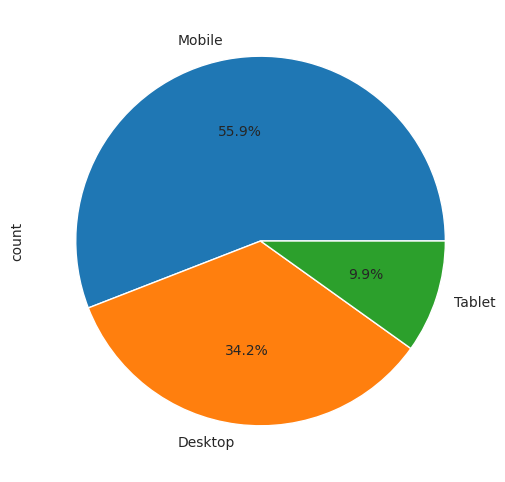

In [31]:
df['Device_Type'].value_counts().plot(kind = 'pie', autopct= '%1.1f%%')
plt.show()

<Axes: ylabel='Payment_Method'>

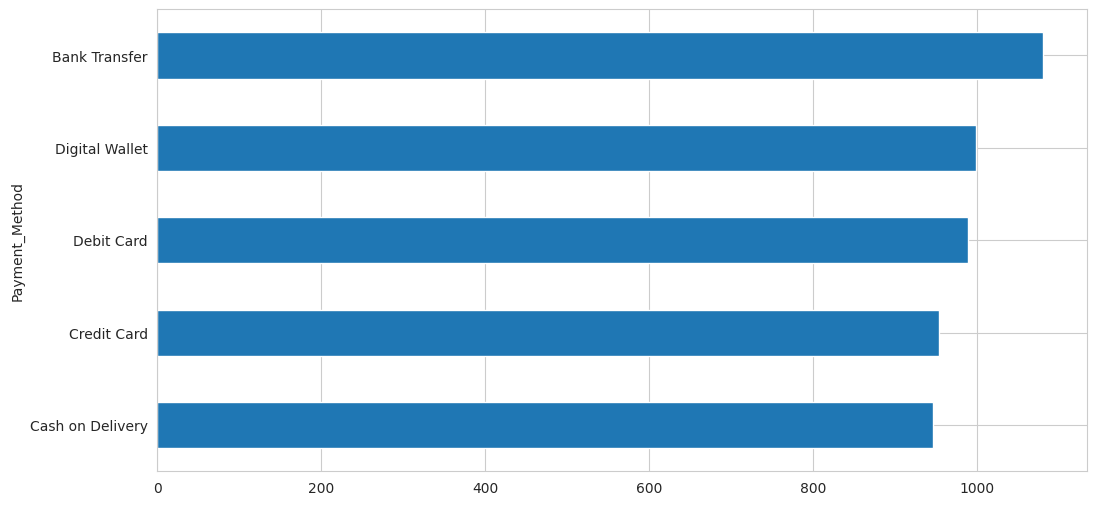

In [32]:
df.groupby("Payment_Method")['Total_Amount'].mean().sort_values().plot(kind = 'barh') #sort max to min

<Axes: xlabel='Customer_Rating'>

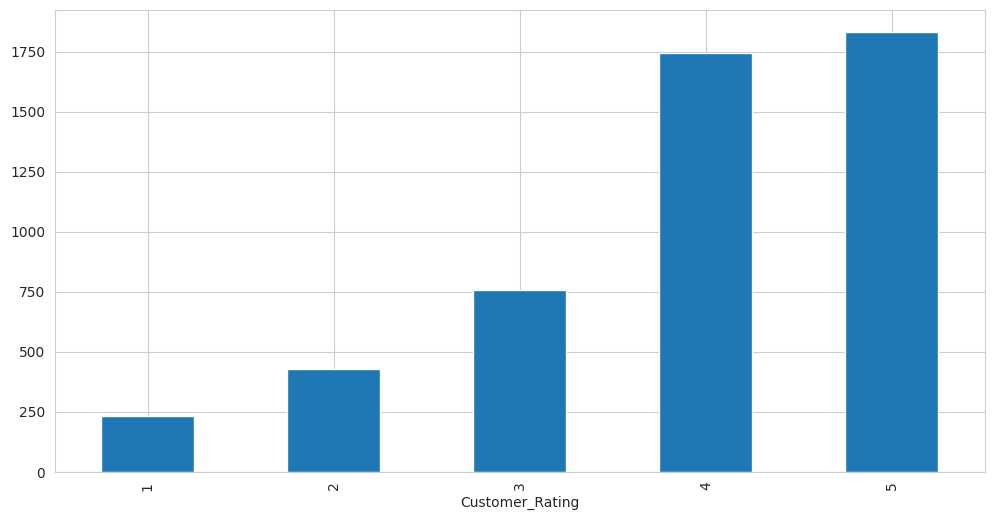

In [33]:
df['Customer_Rating'].value_counts().sort_index().plot(kind = 'bar')


<Axes: xlabel='Product_Category'>

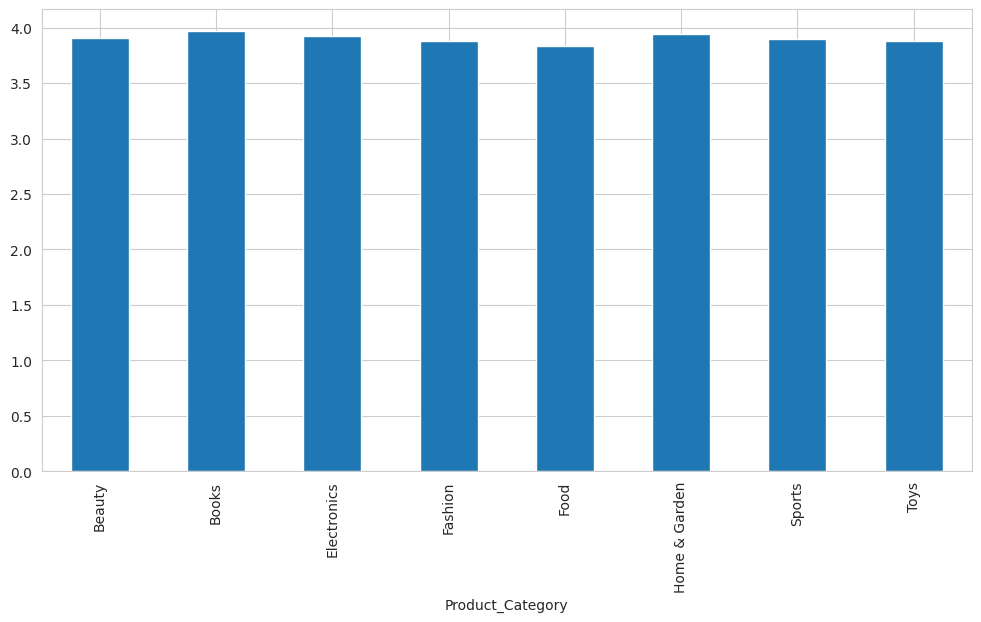

In [34]:
df.groupby('Product_Category')['Customer_Rating'].mean().plot(kind = 'bar') 

In [35]:
df['Year_Month']= df['Date'].dt.to_period('M') # add last column year_month 
#df['Date'] → must be a datetime column
#.dt → lets you access datetime properties
#.to_period('M') → converts each date into a monthly period (e.g. 2026-05)
df

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Year_Month
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5,2023-01
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3,2023-01
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2,2023-01
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4,2023-01
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4,2023-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ORD_001048,CUST_01048,2024-03-26,18,Female,Izmir,Beauty,130.35,1,27.30,103.05,Bank Transfer,Mobile,17,10,False,9,1,2024-03
4996,ORD_001051,CUST_01051,2024-03-26,27,Male,Adana,Beauty,71.55,1,0.00,71.55,Debit Card,Mobile,13,9,True,6,4,2024-03
4997,ORD_003543,CUST_03543,2024-03-26,45,Female,Antalya,Food,39.38,1,5.27,34.11,Digital Wallet,Mobile,38,10,True,5,4,2024-03
4998,ORD_004443,CUST_04443,2024-03-26,41,Female,Istanbul,Fashion,171.19,1,0.00,171.19,Credit Card,Mobile,20,12,True,5,4,2024-03


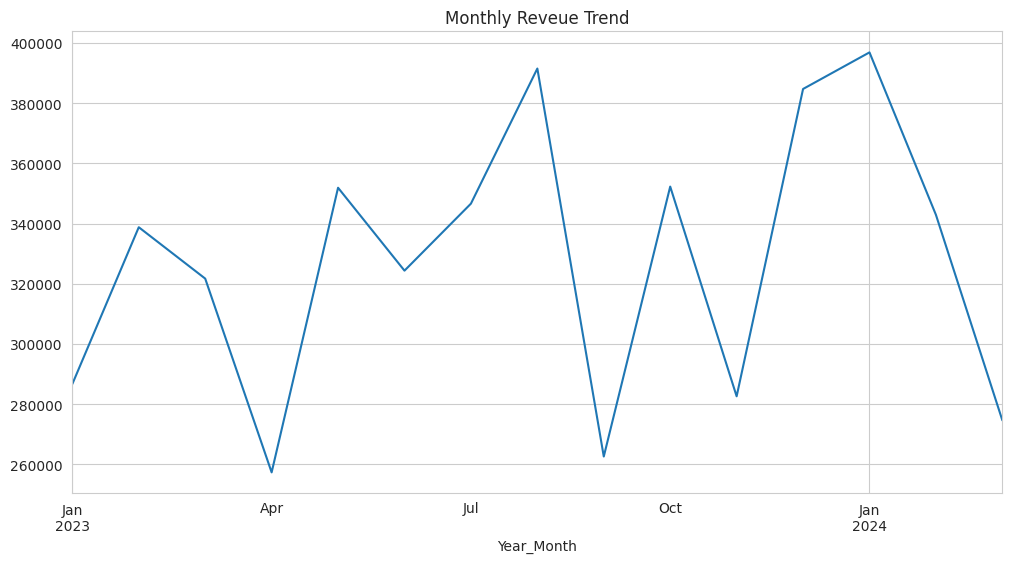

In [36]:
monthly_sales = df.groupby('Year_Month')['Total_Amount'].sum()
monthly_sales.plot(kind = 'line')
plt.title('Monthly Reveue Trend')
plt.show()

<Axes: xlabel='Is_Returning_Customer'>

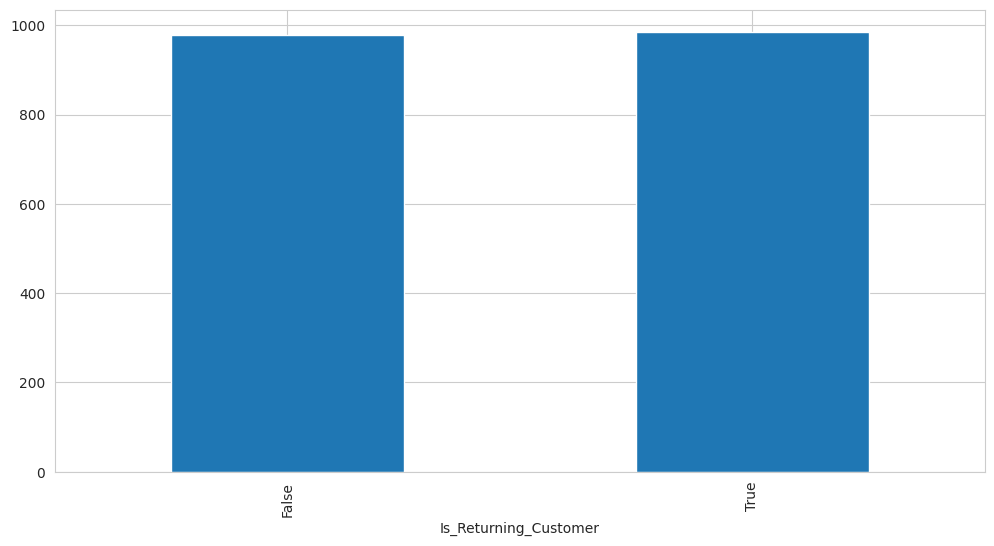

In [37]:
df.groupby('Is_Returning_Customer')['Total_Amount'].mean().plot(kind = 'bar') # how much returning customers spend compared to new customers

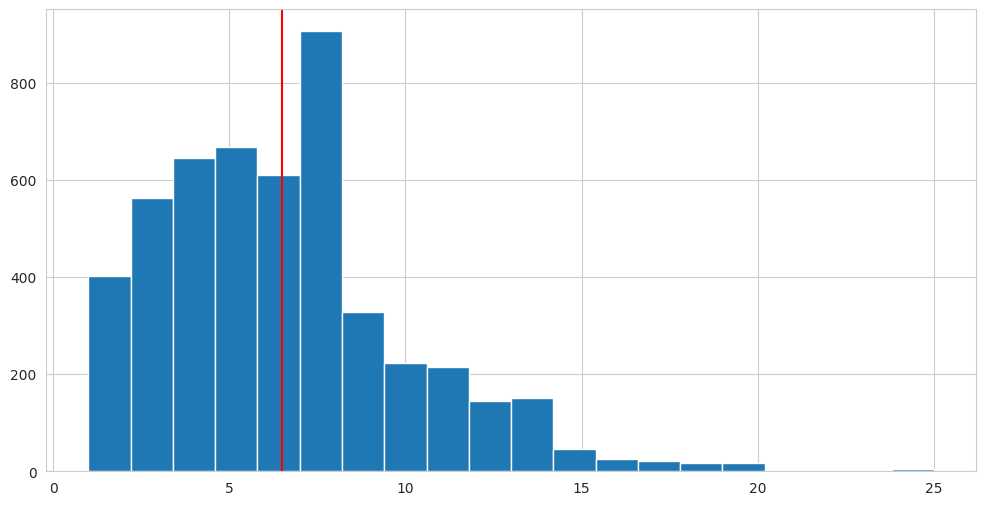

In [38]:
plt.hist(df['Delivery_Time_Days'], bins = 20)
plt.axvline(df['Delivery_Time_Days']. mean(), color = 'red') 

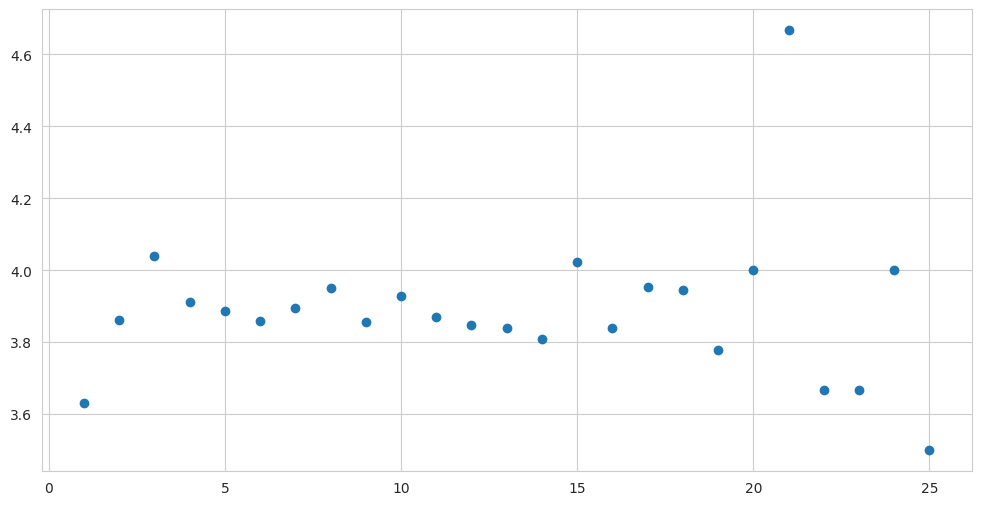

In [39]:
Delivery_rating = df.groupby('Delivery_Time_Days')['Customer_Rating'].mean() #scatter plot of:
# x-axis → Delivery_Time_Days, Delivery_rating.index
# y-axis → Customer_Rating, Delivery_rating.values
plt.scatter(Delivery_rating.index,Delivery_rating.values)